In [1]:
pip install pandas scikit-learn

Note: you may need to restart the kernel to use updated packages.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25192 entries, 0 to 25191
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     25192 non-null  int64  
 1   protocol_type                25192 non-null  object 
 2   service                      25192 non-null  object 
 3   flag                         25192 non-null  object 
 4   src_bytes                    25192 non-null  int64  
 5   dst_bytes                    25192 non-null  int64  
 6   land                         25192 non-null  int64  
 7   wrong_fragment               25192 non-null  int64  
 8   urgent                       25192 non-null  int64  
 9   hot                          25192 non-null  int64  
 10  num_failed_logins            25192 non-null  int64  
 11  logged_in                    25192 non-null  int64  
 12  num_compromised              25192 non-null  int64  
 13  root_shell      

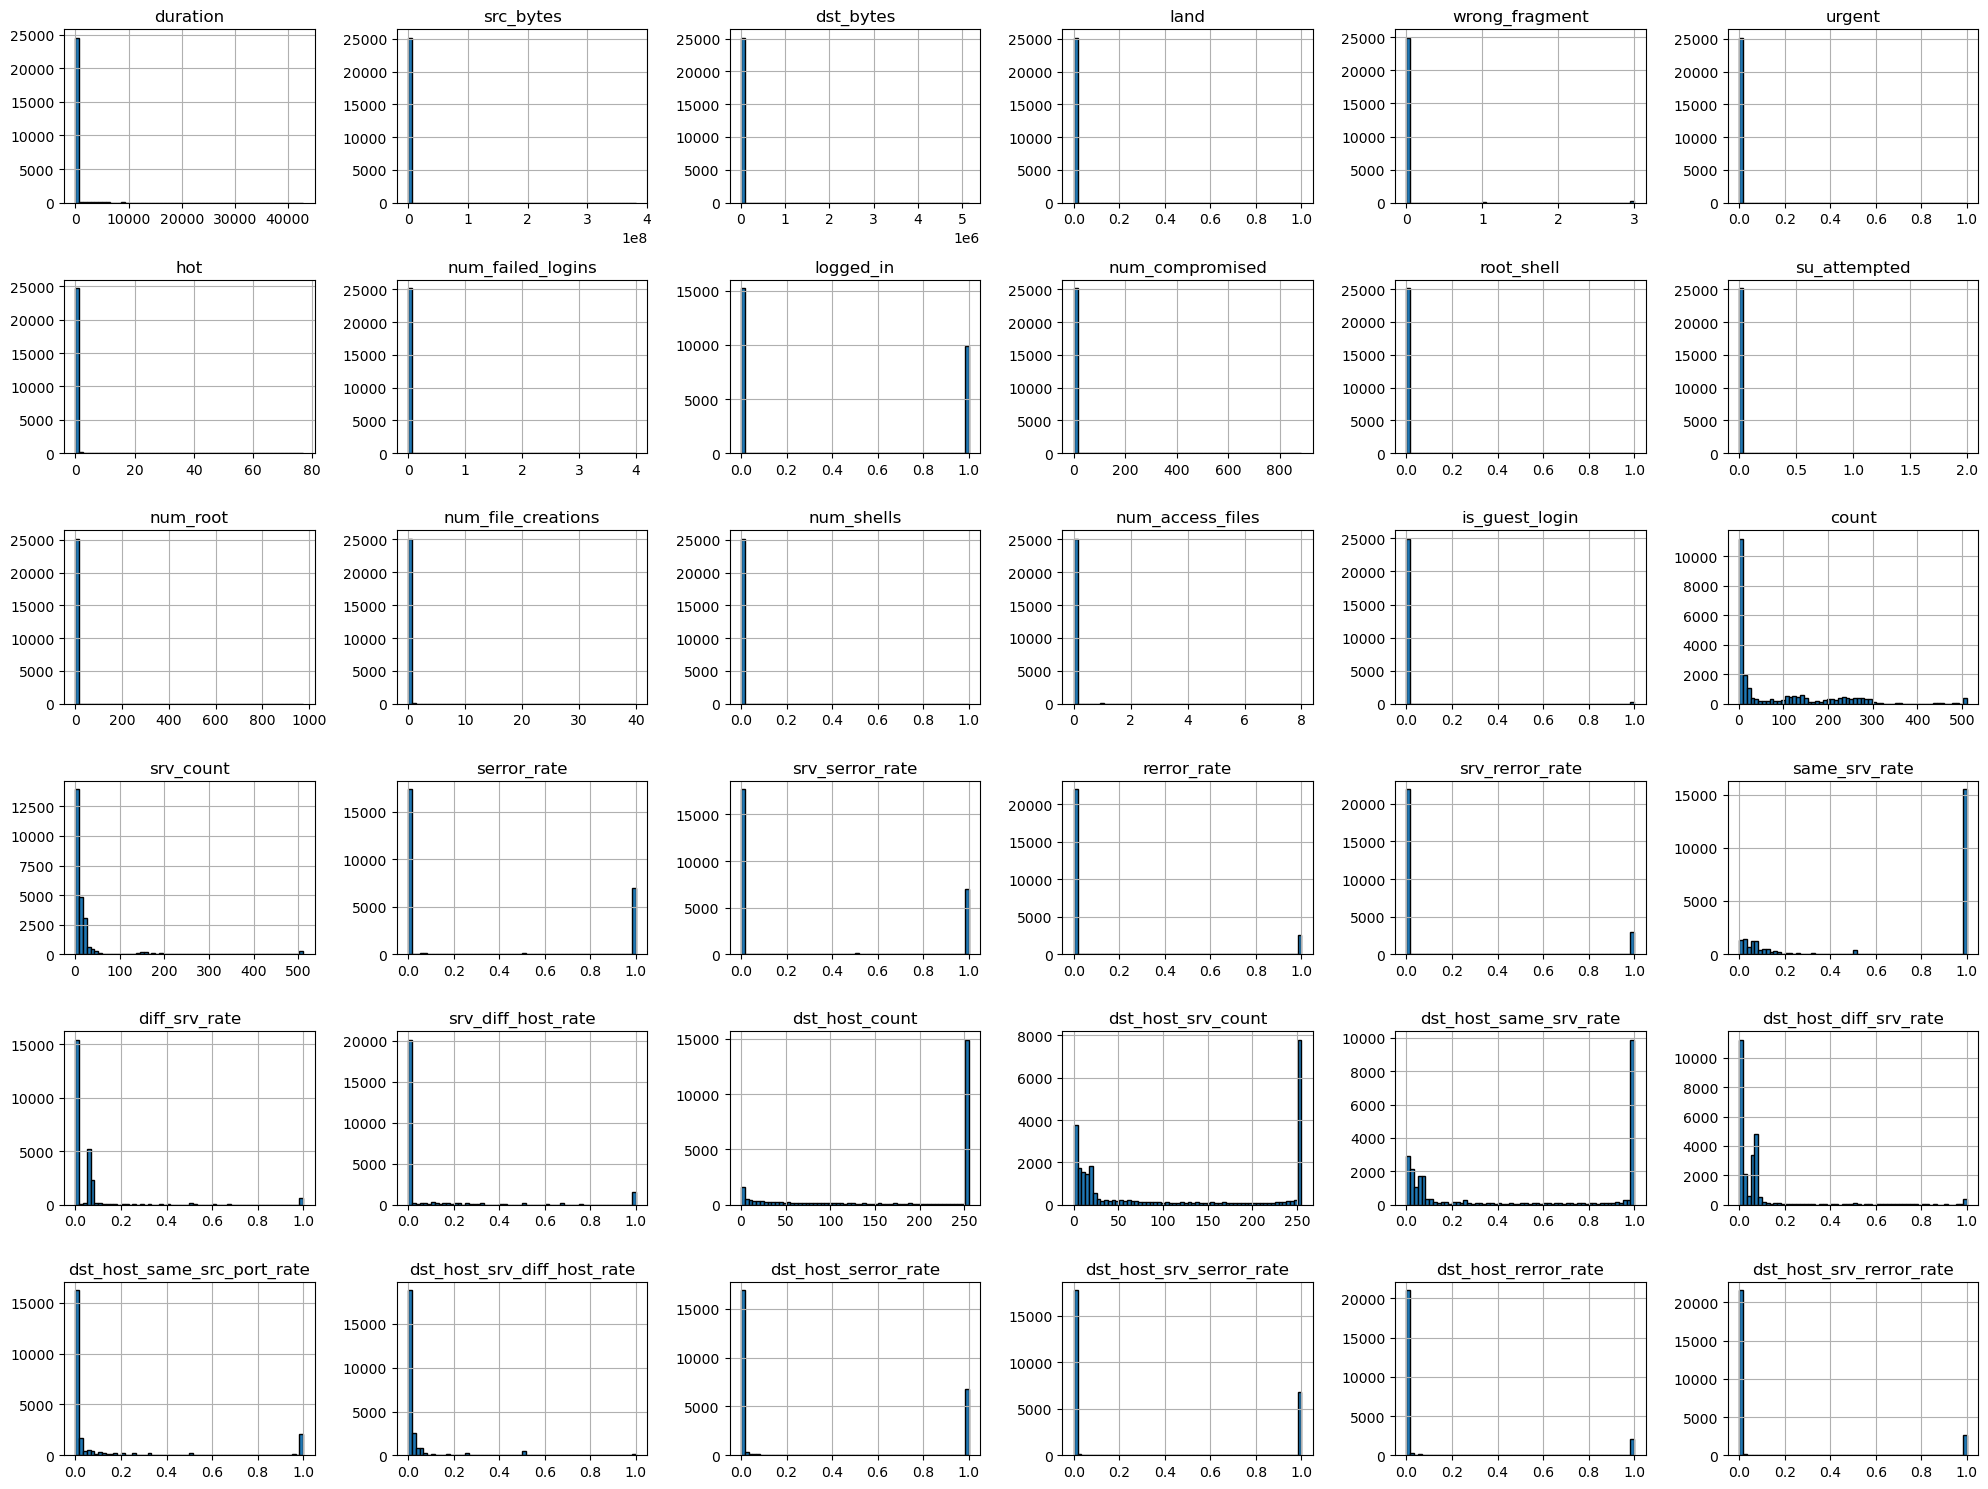

C:\Users\asus\AppData\Local\Temp\ipykernel_16700\1682630516.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values,
C:\Users\asus\AppData\Local\Temp\ipykernel_16700\1682630516.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values,
C:\Users\asus\AppData\Local\Temp\ipykernel_16700\1682630516.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values,


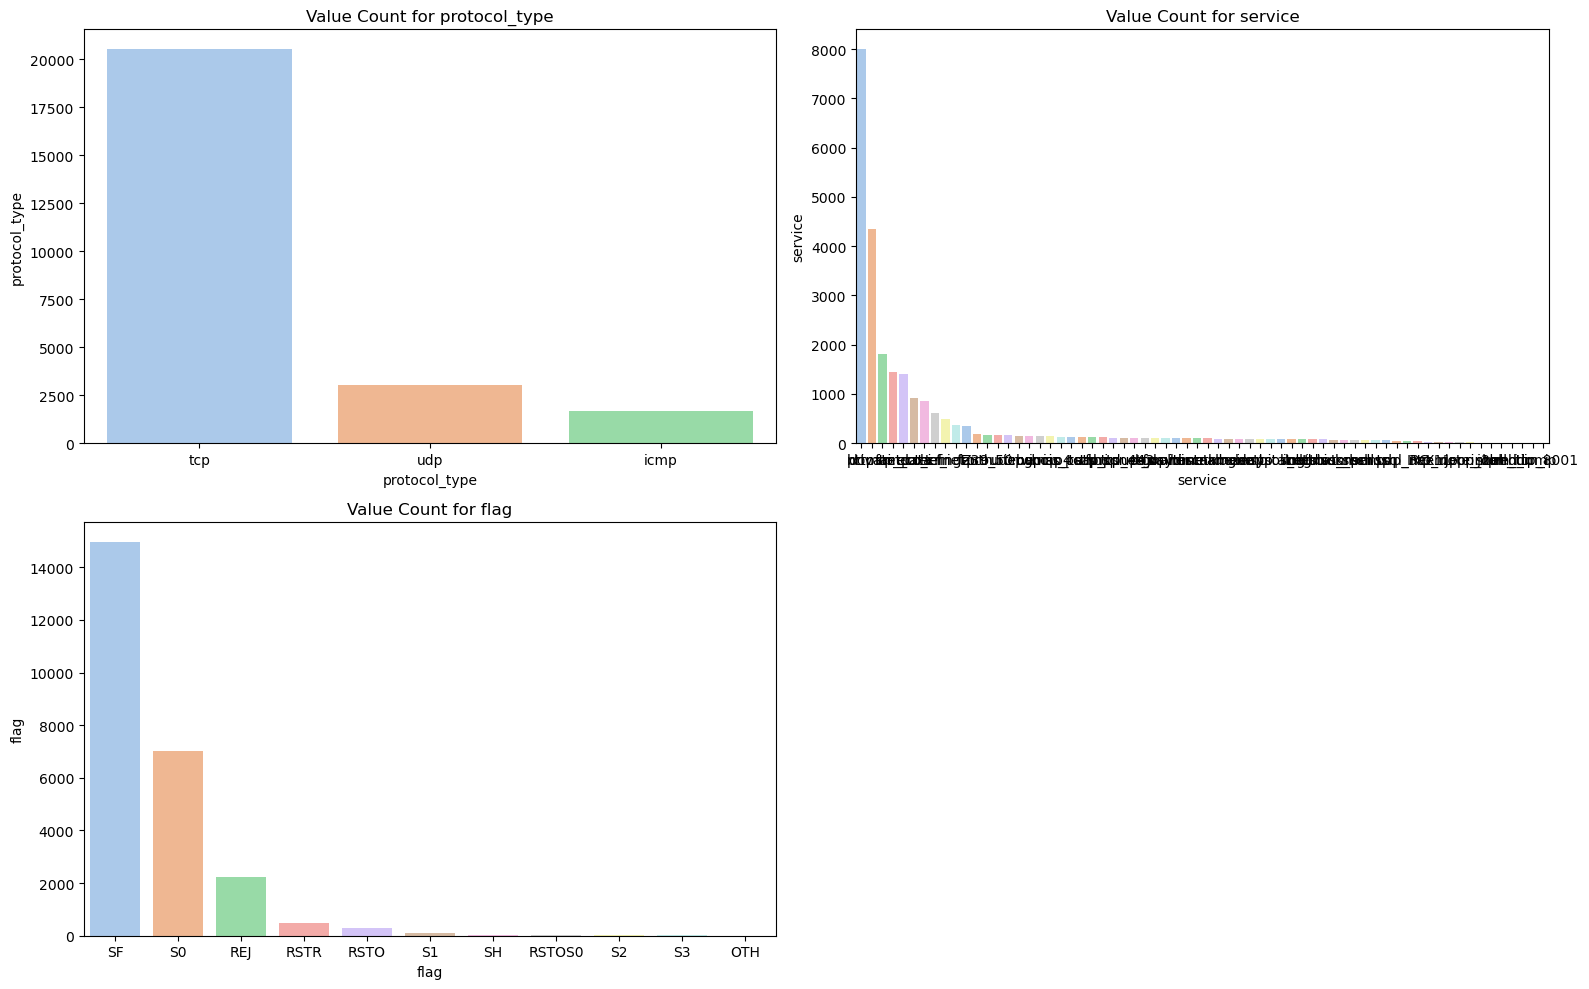

service
http           8003
private        4351
domain_u       1820
smtp           1449
ftp_data       1396
eco_i           909
other           858
ecr_i           613
telnet          483
finger          366
ftp             345
auth            189
Z39_50          172
courier         164
uucp            157
time            155
bgp             146
whois           145
imap4           138
uucp_path       133
iso_tsap        131
ctf             127
urp_i           124
nnsp            123
supdup          114
http_443        113
csnet_ns        111
efs             110
domain          109
gopher          109
daytime         107
vmnet           107
discard         105
hostnames        96
name             92
klogin           92
exec             91
ldap             90
mtp              90
systat           88
netbios_dgm      85
link             85
login            79
netstat          78
netbios_ns       76
netbios_ssn      67
sunrpc           67
kshell           67
echo             65
nntp        

In [3]:
import os
import math

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


keras.utils.set_random_seed(42)

for dirname, _, filenames in os.walk("kaggle inputs"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

pd.set_option('display.max_columns', None)


df_train = pd.read_csv(r'C:\Users\asus\Downloads\Train_data.csv.zip')
df_test  = pd.read_csv(r'C:\Users\asus\Downloads\Test_data.csv.zip')


df_train.info()
print(df_train)
print(df_test)


print("Column diff:", set(df_train.columns) ^ set(df_test.columns))


numeric_cols = df_train.select_dtypes(include=np.number).columns
object_cols  = df_train.select_dtypes(include=object).columns

print(df_train.describe())

df_train_std_0_cols = (
    df_train[numeric_cols]
    .columns[df_train[numeric_cols].std() == 0]
    .tolist()
)
print(f'df_train std==0 columns: {df_train_std_0_cols}')

df_train     = df_train.drop(columns=df_train_std_0_cols)
numeric_cols = numeric_cols.drop(df_train_std_0_cols)


print(df_train.isna().sum())


df_train[numeric_cols].hist(figsize=(20, 15), bins=60, edgecolor='black')
plt.tight_layout()
plt.show()



plot_cols = object_cols.drop('class')          
num_categorical_cols = len(plot_cols)
graph_cols = 2
nrows = math.ceil(num_categorical_cols / graph_cols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=graph_cols,
    figsize=(8 * graph_cols, 5 * nrows)
)

axes_flat = np.array(axes).flatten()           # always 1-D

for ix, col in enumerate(plot_cols):
    value_counts = df_train[col].value_counts()
    sns.barplot(x=value_counts.index, y=value_counts.values,
                palette="pastel", ax=axes_flat[ix])
    axes_flat[ix].set_title(f"Value Count for {col}")
    axes_flat[ix].set_ylabel(col)

for ix in range(num_categorical_cols, len(axes_flat)):
    axes_flat[ix].set_visible(False)

plt.tight_layout()
plt.show()


dmr = pd.get_option('display.max_rows')
pd.set_option('display.max_rows', None)
print(df_train['service'].value_counts())
pd.set_option('display.max_rows', dmr)


print(df_train['class'].value_counts())

df_train_normal_mask  = df_train['class'] == 'normal'
df_train_anomaly_mask = df_train['class'] == 'anomaly'